# MD 처방 파이프라인 — 단일추론 → 차분행렬 → 처방 → 검증·KPI (exp47 leak-free)

> 계획: `docs/eda_channel_prescription_plan.md` (Plan 2) · `docs/final_model_leakfree_switch_plan.md` (Plan 1)
> 모듈: `src/eval/md/{engine,tasks,prescription,validate}.py`

```
[Stage 1] 단일 추론 캐시        eng = MDEngine().run_single_inference()  →  prob·y·att24·Mass·장부(full/train)
    │                            (원칙 0: 전체 forward 1회. 이후 슬라이싱/조건부 집계)
    ▼
[Stage 2] 집계·차분 행렬        g1 = stage_g1_macro(eng)      성공망 vs 실패망 (A_diff±)
    │                            g2 = stage_g2_channel(eng)    POS 독점망 vs 인스타 독점망
    │                            cell_4a/4b/4c                  혼동행렬 구조 진단 (within-channel)
    ▼
[Stage 3] 처방 엔진 바인딩      pe = MDPrescriptionEngine(eng, g2)  →  get_md_prescription(seed)
    │                            §5: 장바구니·A빔·B anti·C 포화/신흥·E 견고성·F 소생
    ▼
[Stage 4] 검증·KPI 스코어보드   validate.run_all(eng, pe)     Tier1 순열·Tier2 holdout·Tier4 개입·Tier5 시너지·Precision@K
    │
    ▼
[Stage 5] 자동 저장             OUT_DIR/{inference_cache.npz, ledgers.parquet, engine_meta.json, scoreboard.json, figures/}
```
전역 객체 `eng·g1·g2·pe·scoreboard` 가 셀 간 메모리로 유기적으로 연결됩니다.

In [1]:
# --- Setup ---
import os, sys, json
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))  # repo root (notebooks/ → ../../)
if ROOT not in sys.path: sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False

from src.eval.md.engine import MDEngine, EngineConfig
from src.eval.md import tasks as T
from src.eval.md.prescription import MDPrescriptionEngine, get_md_prescription
from src.eval.md import validate as V
print("repo:", ROOT)

C:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo: C:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework


## 🔀 모델 선택 — exp47 vs v2_sweepA

| | exp47 (현 서빙) | v2_sweepA (검증 우세) |
|---|---|---|
| 구조 | HINGNN, copurchase 제거 | HINGNNv2(멀티태스크) + basket_comp 엣지 |
| 누수 | leak-free | leak-free |
| test PR-AUC | 0.570 | **0.606** |
| test 운영점 F1 | 0.544 | **0.583** |
| 과적합 gap | 0.215 | **0.135** |

`MODEL` 한 줄만 바꿔 두 모델 중 선택. 출력은 모델별 폴더로 분리 저장됩니다.

In [ ]:
# ── 모델 선택 (여기만 바꾸면 됨) ──
MODEL = "v2_sweepA"      # "v2_sweepA"(최종 채택)  또는  "exp47"

ENGINE_CFG = EngineConfig.exp47() if MODEL == "exp47" else EngineConfig.v2_sweepA()
OUT_DIR = f"experiments/results/md_prescription/{MODEL}"
FIG_DIR = os.path.join(OUT_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)
print(f"선택 모델: {MODEL}  | exp_dir={ENGINE_CFG.exp_dir}  | THR={ENGINE_CFG.thr}  | out={OUT_DIR}")

## Stage 1 — 단일 추론 캐시 (원칙 0: 전체 forward 1회)

In [3]:
eng = MDEngine(ENGINE_CFG).run_single_inference()
eng.build_mass()
lg_full  = eng.build_ledger("full")
lg_train = eng.build_ledger("train")
c = eng.cache
print(f"[{MODEL}] is_v2={getattr(eng,'is_v2',False)}  | P/K/I = {c['P']}/{c['K']}/{c['I']}  | base={c['base_rate']:.3f}  | THR={eng.cfg.thr}")
print(f"att 관계 {len(c['att'])}종 | prob 평균 {c['prob'].mean():.3f}")
print(f"장부(full)  killer={len(lg_full.killer)} mine={len(lg_full.mine)} hub={len(lg_full.hub)}")
print(f"장부(train) killer={len(lg_train.killer)} mine={len(lg_train.mine)} hub={len(lg_train.hub)}")

[exp47] is_v2=False  | P/K/I = 5033/2063/335  | base=0.238  | THR=0.7755
att 관계 20종 | prob 평균 0.325
장부(full)  killer=62 mine=131 hub=144
장부(train) killer=56 mine=123 hub=119


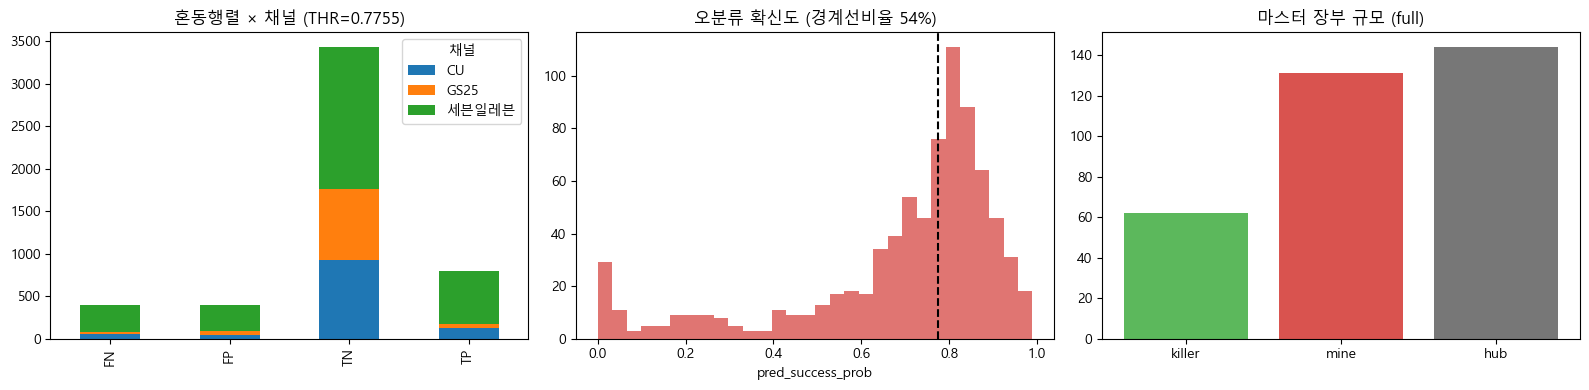

In [4]:
# Stage 1 대시보드: 혼동행렬 × 채널 + 오분류 확신도 + 장부 규모
diag = T.cell_4a(eng)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ct = diag["crosstab"].drop(index="All", errors="ignore").drop(columns="All", errors="ignore")
ct.plot(kind="bar", stacked=True, ax=ax[0]); ax[0].set_title(f"혼동행렬 × 채널 (THR={eng.cfg.thr})"); ax[0].set_xlabel("")
ax[1].hist(diag["prob_err"], bins=30, color="#d9534f", alpha=.8); ax[1].axvline(eng.cfg.thr, ls="--", c="k")
ax[1].set_title(f"오분류 확신도 (경계선비율 {diag['borderline_frac']:.0%})"); ax[1].set_xlabel("pred_success_prob")
ax[2].bar(["killer","mine","hub"], [len(lg_full.killer),len(lg_full.mine),len(lg_full.hub)], color=["#5cb85c","#d9534f","#777"])
ax[2].set_title("마스터 장부 규모 (full)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"stage1_dashboard.png"), dpi=110, bbox_inches="tight"); plt.show()

## Stage 2 — 집계·차분 행렬 (거시 G-1 / 미시 G-2) + 혼동행렬 구조 진단

In [5]:
g1   = T.stage_g1_macro(eng)                 # 성공망 vs 실패망
g2   = T.stage_g2_channel(eng, "track1")     # 전 채널 POS vs 인스타 (처방 주 신호원)
g2b  = T.stage_g2_channel(eng, "track2")     # 세븐 한정 검증 트랙
print("G-1 A_diff+ nnz:", int((g1.A_diff_plus>0).sum()), "| A_diff- nnz:", int((g1.A_diff_minus>0).sum()))
print("G-2(track1) POS독점망 nnz:", int((g2.A_diff_pos>0).sum()), "| 인스타독점망 nnz:", int((g2.A_diff_insta>0).sum()))

G-1 A_diff+ nnz: 31852 | A_diff- nnz: 52747
G-2(track1) POS독점망 nnz: 27112 | 인스타독점망 nnz: 7612


In [6]:
# Cell 4b — 분면별 1-hop 위상 대조 (within-channel)
display(T.cell_4b(eng, within_channel=True))
# Cell 4c — 극단 오분류 Top
ext = T.cell_4c(eng, top_k=8)
print("── 가장 억울한 FN (저prob 성공) ──"); display(ext["FN"])
print("── 가장 황당한 FP (고prob 실패) ──"); display(ext["FP"])

degree  hubness  ip_count  killer_ratio  mine_ratio
channel quad                                                     
CU      FN    27.608    0.604     0.373         0.046       0.057
        FP    26.186    1.469     0.698         0.018       0.028
        TN    22.657    0.224     0.181         0.025       0.078
        TP    28.157    0.942     0.760         0.052       0.030
GS25    FN    31.760    0.208     0.720         0.067       0.073
        FP    26.196    1.183     0.451         0.015       0.044
        TN    22.651    0.196     0.373         0.026       0.088
        TP    31.111    1.149     1.315         0.040       0.038
세븐일레븐   FN    23.830    0.430     0.077         0.030       0.070
        FP    25.859    0.929     0.180         0.035       0.032
        TN    19.669    0.010     0.094         0.020       0.115
        TP    26.047    0.737     0.309         0.053       0.036

── 가장 억울한 FN (저prob 성공) ──


,product,channel,prob,neighbors
0,훼밀리)사과무케루푸루푸루구미40g,세븐일레븐,0.0,"무[n], 사과[h], 과일[n], 젤리[h]"
1,요아정요거트초코쉘팝팝콘딸,GS25,0.0,"쉘[n], CJ[n], 농심[n], 팝콘[h], 롯데[h], 요거트[n], 딸기[h..."
2,젼언니과일모양프룻팝스,GS25,0.0,"과즙[n], 포도[m], 망고[h], 복숭아[m], 과일[n], 딸기[h], 디저트..."
3,PB)요구르트280ml,세븐일레븐,0.0,"유산균[n], 요거트[n], 간식[h]"
4,훼밀리)포도무케루푸루푸루구미40g,세븐일레븐,0.0,"포도[m], 젤리[h], 간식[h]"
5,NCTDREAMXGS25아이돌컴백샌드위치,GS25,0.0,"NCT[n], 아이돌[n], 샌드위치[k], 샌드[n], 빵[h]"
6,초코비의짜장라면,CU,0.0,"짜장[m], 어묵[h], 라면[h], 쫄깃함[n], 초코[h], 야식[n], 간식[h]"
7,제스)모리나가밀크카라멜모나카97g,세븐일레븐,0.0,"모나카[n], 일본[n], 밀크[n], 카라멜[h], 디저트[h], 간식[h]"


── 가장 황당한 FP (고prob 실패) ──


,product,channel,prob,neighbors
0,크림치즈구름빵,GS25,0.990,"구름[n], 치즈[h], 빵[h], 크림[h]"
1,소세지피자빵초코케이크,GS25,0.989,"피자[h], 소시지[n], 케이크[h], 치즈[h], 빵[h], 초코[h]"
2,TXT별모아쿠키,CU,0.988,"쿠키[h], 시즌[n], 과자[h], 고소[h]"
3,밀팜)39초코스콘슈120g,세븐일레븐,0.985,"스콘[n], 슈[h], 당[n], 초코[h], 디저트[h], 달콤[h], 간식[h]"
4,PB)디저트39솔티카라멜우유500ml,세븐일레븐,0.983,"솔티[n], 카라멜[h], 저당[n], 우유[h], 짭조름함[h], 디저트[h], ..."
5,야끼소바도그,CU,0.978,"야끼소바[h], 가쓰오부시[n], 핫도그[h], 마요[n], 콜라[n], 짭조름함[..."
6,KBO돌직구딸기비스킷,CU,0.977,"비스킷[n], 담백[n], 새콤[h], 딸기[h], 과자[h], 바삭[n], 달콤[..."
7,맛제일)스팸아라비아따파스타,세븐일레븐,0.975,"아라비아따[n], CJ[n], 스팸[n], 파스타[n], 콜라보[n], 콜라[n],..."


## Stage 3 — 처방 엔진 바인딩 (§5: 장바구니·A~F)

In [7]:
pe = MDPrescriptionEngine(eng, g2, universe="full")
for seed in ["마라","로제","단백질","흑임자","위스키"]:
    print("="*70); print(get_md_prescription(pe, seed))

MD님께서 활용하실 '마라' 키워드는 성공 특이망 분석 결과 [기획 반려] 대상입니다. (포화도: 레드오션(포화·자기잠식 위험) · 근거 신뢰도: 높음/지지도 63)
· 함께 조합할 [도쿠시마, 짜파게티, 마파, 두부] 속성은 POS 매출 독점망 기반 → 제품 속성으로 내실화하십시오.
· [정통, 탕, 국물, 쫄깃함] 속성은 인스타 반응 독점망 기반 → 초기 마케팅 카피로 활용하십시오.
· ⚠ 피해야 할 조합(점수 하락): [탄탄, 적음, 깊은맛, 샹궈].
· 🛒 장바구니 보완재(번들 제안): 위스트)마라곤약 향라맛(383.86), 오뚜기)고단백컵누들매콤로제(146.7), 농심)누들핏마라탄탄(31.49).
· 💉 점수 보강이 필요하면 [알포트, 포카칩, 흰, 뷰티] 추가를 검토하십시오.


MD님께서 활용하실 '로제' 키워드는 성공 특이망 분석 결과 [중립] 대상입니다. (포화도: 레드오션(포화·자기잠식 위험) · 근거 신뢰도: 높음/지지도 23)
· 함께 조합할 [늘어남, 마카로니, 파마산, 당면] 속성은 POS 매출 독점망 기반 → 제품 속성으로 내실화하십시오.
· [분식, 꾸덕함, 불닭, 떡볶이] 속성은 인스타 반응 독점망 기반 → 초기 마케팅 카피로 활용하십시오.
· ⚠ 피해야 할 조합(점수 하락): [떡볶이, 파마산, 고단백, 토핑].
· 🛒 장바구니 보완재(번들 제안): 앙리마티스)하트와인볼(로제)500ml캔(174.15), 오뚜기)고단백컵누들마라샹궈(146.7), 카브루)말차하이볼500ml캔(67.86).
· 💉 점수 보강이 필요하면 [알포트, 포카칩, 흰, 뷰티] 추가를 검토하십시오.


MD님께서 활용하실 '단백질' 키워드는 성공 특이망 분석 결과 [중립] 대상입니다. (포화도: 레드오션(포화·자기잠식 위험) · 근거 신뢰도: 높음/지지도 95)
· 함께 조합할 [엽떡, 동물, 아르기닌, 이지프로틴] 속성은 POS 매출 독점망 기반 → 제품 속성으로 내실화하십시오.
· [(없음)] 속성은 인스타 반응 독점망 기반 → 초기 마케팅 카피로 활용하십시오.
· ⚠ 피해야 할 조합(점수 하락): [소이조이, 글루텐프리, 헬스, 피쉬].
· 🛒 장바구니 보완재(번들 제안): CJ)더건강한저당닭가슴살숯불치킨맛120g(2634.04), 동원)어단백피쉬프로틴바닭가슴살70g(451.58), 써라클)베노프단백질바(트러플피넛)50g(351.92).
· 💉 점수 보강이 필요하면 [알포트, 포카칩, 흰, 뷰티] 추가를 검토하십시오.


MD님께서 활용하실 '흑임자' 키워드는 성공 특이망 분석 결과 [중립] 대상입니다. (포화도: 레드오션(포화·자기잠식 위험) · 근거 신뢰도: 높음/지지도 14)
· 함께 조합할 [공룡, 알, 묵직함, 컵] 속성은 POS 매출 독점망 기반 → 제품 속성으로 내실화하십시오.
· [마카롱, 바나나, 바닐라, 콜라] 속성은 인스타 반응 독점망 기반 → 초기 마케팅 카피로 활용하십시오.
· 🛒 장바구니 보완재(번들 제안): 삼립)잘익은쑥이야기110g(77.63), KBO)키움히어로즈자색고구마팡100g(56.56), KBO)NC다이노스공룡알흑임자컵케익130g(56.55).
· 💉 점수 보강이 필요하면 [알포트, 뷰티, 하와이, 포카칩] 추가를 검토하십시오.


MD님께서 활용하실 '위스키' 키워드는 성공 특이망 분석 결과 [중립] 대상입니다. (포화도: 레드오션(포화·자기잠식 위험) · 근거 신뢰도: 높음/지지도 148)
· 함께 조합할 [예술, 블랙서클, 메이커스마크, 캐리비안] 속성은 POS 매출 독점망 기반 → 제품 속성으로 내실화하십시오.
· [막걸리, 하이볼, 야식] 속성은 인스타 반응 독점망 기반 → 초기 마케팅 카피로 활용하십시오.
· ⚠ 피해야 할 조합(점수 하락): [글렌피딕, 임페리얼].
· 🛒 장바구니 보완재(번들 제안): 신동엽)블랙서클위스키700ml(103.83), 하정우)마키키쇼비뇽블랑750ml(110.4).
· 💉 점수 보강이 필요하면 [알포트, 포카칩, 흰, 뷰티] 추가를 검토하십시오.


## Stage 4 — 실시간 검증 · KPI 스코어보드 (Tier1·2·4·5 + Precision@K)

In [8]:
scoreboard = V.run_all(eng, pe, light=True)   # light=False면 순열 500회·표본 확대
rows = []
def _row(name, val, passed, note):
    rows.append(dict(검증=name, 값=val, 통과=("✅" if passed else "⚠️"), 비고=note))
t1=scoreboard["tier1_permutation"]; _row("Tier1 순열귀무", f"{t1['pass_rate']:.0%}", t1['pass_rate']>=0.7, f"killer {t1['n_killer']}개 중 95pct 초과")
t2=scoreboard["tier2_holdout"];    _row("Tier2 holdout", f"PRAUC {t2['test_prauc']} / base {t2['base']}", t2['passed'], f"CI_lo {t2['ci_lo']}")
t4=scoreboard["tier4_intervention"];_row("Tier4 개입(faithful)", f"killer {t4['killer_pos_rate']} vs rand {t4['random_pos_rate']}", t4['passed'], f"mine 비상승 {t4['mine_nonpos_rate']}")
t5=scoreboard["tier5_synergy"];    _row("Tier5 조합시너지", f"초가법 {t5['superadd_rate']}", t5['superadd_rate']>0.0, f"n={t5['n']}")
bk=scoreboard["backtest_precision_at_k"]; _row("KPI Precision@K", f"P@k {bk['precision_at_k']} / hit {bk['hit_rate']}", bk['precision_at_k']>0.0, f"n={bk['n']} (랜덤≈0.5%)")
board = pd.DataFrame(rows); display(board)

C:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


,검증,값,통과,비고
0,Tier1 순열귀무,84%,✅,killer 62개 중 95pct 초과
1,Tier2 holdout,PRAUC 0.2832 / base 0.2387,✅,CI_lo 0.243
2,Tier4 개입(faithful),killer 0.65 vs rand 0.35,⚠️,mine 비상승 0.55
3,Tier5 조합시너지,초가법 0.0,⚠️,n=10
4,KPI Precision@K,P@k 0.0775 / hit 0.25,✅,n=40 (랜덤≈0.5%)


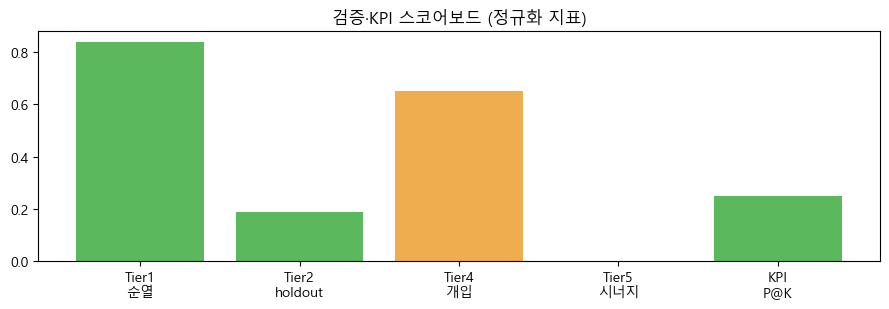

In [9]:
# KPI 스코어보드 시각화
fig, ax = plt.subplots(figsize=(9,3.2))
labels=["Tier1\n순열","Tier2\nholdout","Tier4\n개입","Tier5\n시너지","KPI\nP@K"]
vals=[t1['pass_rate'], t2['test_prauc']/max(t2['base'],1e-9)-1, t4['killer_pos_rate'], t5['superadd_rate'], bk['hit_rate']]
cols=["#5cb85c" if p else "#f0ad4e" for p in [t1['pass_rate']>=0.7,t2['passed'],t4['passed'],t5['superadd_rate']>0,bk['precision_at_k']>0]]
ax.bar(labels, vals, color=cols); ax.set_title("검증·KPI 스코어보드 (정규화 지표)"); ax.axhline(0, c="k", lw=.5)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR,"stage4_scoreboard.png"), dpi=110, bbox_inches="tight"); plt.show()

## Stage 5 — 제안 파일 구조로 자동 저장

In [10]:
# 캐시·장부·메타 저장 (engine.save_cache) + 스코어보드 + 처방 샘플 + 그림
eng.save_cache(OUT_DIR)
with open(os.path.join(OUT_DIR,"scoreboard.json"),"w",encoding="utf-8") as f:
    json.dump(scoreboard, f, ensure_ascii=False, indent=2, default=lambda o: o.tolist() if hasattr(o,'tolist') else str(o))
with open(os.path.join(OUT_DIR,"prescriptions_sample.txt"),"w",encoding="utf-8") as f:
    for seed in ["마라","로제","단백질","흑임자","위스키"]:
        f.write("="*70+"\n"+get_md_prescription(pe, seed)+"\n")
board.to_csv(os.path.join(OUT_DIR,"scoreboard.csv"), index=False, encoding="utf-8-sig")

print("저장 완료 →", OUT_DIR)
for root,_,files in os.walk(OUT_DIR):
    for fn in sorted(files):
        p=os.path.join(root,fn); print(f"  {os.path.relpath(p,OUT_DIR):40s} {os.path.getsize(p):>10,} B")

저장 완료 → experiments/results/md_prescription/exp47
  engine_meta.json                                347 B
  inference_cache.npz                          45,273 B
  ledgers.parquet                              31,675 B
  prescriptions_sample.txt                      4,603 B
  scoreboard.csv                                  334 B
  scoreboard.json                               1,202 B
  figures\stage1_dashboard.png                 37,005 B
  figures\stage4_scoreboard.png                13,746 B
